# RiMEA 15: Movement of a Large Crowd of Pedestrians Around a Corner

The goal is to assess the extent to which the movement of persons around a corner affects the calculated evacuation time. 3 scenarios are constructed: Scenario 1 has a 20 m x 81.4 m straight corridor geometry, whereas Scenario 2 has a curve and Scenario 3 has a shorter corridor of the dimensions 20 m x 50 m (RiMEA Guideline 4.1.1 Fig. 19). Time taken for all persons to reach the destination is compared to determine how much a corner influences a simulation result. Ideally, the result from the "corner" would be in between the two results for Scenario 1 and Scenario 3.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 25 June 2026, 13:22 CEST


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon
from shapely.plotting import plot_polygon
import jupedsim as jps
from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

##  Load and Run Scenario 1

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Rimea-15-large-crowd-corner-1.zip"
scenario1 = load_scenario(str(SCENARIO_ZIP))
print(scenario1.summary())
result1 = run_scenario(scenario1, seed=42)
walkable1 = scenario1.walkable_polygon
df1 = result1.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-15-large-crowd-corner-1.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~500
    jps-distributions_0: 500 agents
DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 500, 'radius': 0.2, 'v0': 1.2, 'flow_start_time': 0, 'flow_end_time': 10, 'percentage': None, 'distribution_mode': 'by_number', 'use_flow_spawning': False, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 500, 'radius': 0.2, 'v0': 1.2, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'p

## Load and Run Scenario 2

In [5]:
SCENARIO_ZIP = Path("scenario_files") / "Rimea-15-large-crowd-corner-2.zip"
scenario2 = load_scenario(str(SCENARIO_ZIP))
print(scenario2.summary())
result2 = run_scenario(scenario2, seed=42)
walkable2 = scenario2.walkable_polygon
df2 = result2.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-15-large-crowd-corner-2.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~500
    jps-distributions_0: 500 agents
DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 500, 'radius': 0.2, 'v0': 1.2, 'flow_start_time': 0, 'flow_end_time': 10, 'percentage': None, 'distribution_mode': 'by_number', 'use_flow_spawning': False, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 500, 'radius': 0.2, 'v0': 1.2, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'p

## Load and Run Scenario 3

In [6]:
SCENARIO_ZIP = Path("scenario_files") / "Rimea-15-large-crowd-corner-3.zip"
scenario3 = load_scenario(str(SCENARIO_ZIP))
print(scenario3.summary())
result3 = run_scenario(scenario3, seed=42)
walkable3 = scenario3.walkable_polygon
df3 = result3.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-15-large-crowd-corner-3.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~500
    jps-distributions_0: 500 agents
DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 500, 'radius': 0.2, 'v0': 1.2, 'flow_start_time': 0, 'flow_end_time': 10, 'percentage': None, 'distribution_mode': 'by_number', 'use_flow_spawning': False, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 500, 'radius': 0.2, 'v0': 1.2, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'p

## Exit Times of All Scenarios

In [7]:
def get_exit_times(df, result):
    et = (
        df.sort_values(["id", "frame"])
        .groupby("id")
        .tail(1)[["id", "frame"]]
        .rename(columns={"frame": "exit_frame"})
    )
    et["exit_time"] = et["exit_frame"] / result.frame_rate
    return et

exit_times1 = get_exit_times(df1, result1)
exit_times2 = get_exit_times(df2, result2)
exit_times3 = get_exit_times(df3, result3)

print("Max exit time (df1):", exit_times1["exit_time"].max())
print("Max exit time (df2):", exit_times2["exit_time"].max())
print("Max exit time (df3):", exit_times3["exit_time"].max())

Max exit time (df1): 125.4
Max exit time (df2): 235.3
Max exit time (df3): 106.9


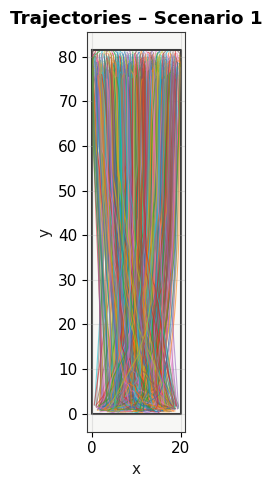

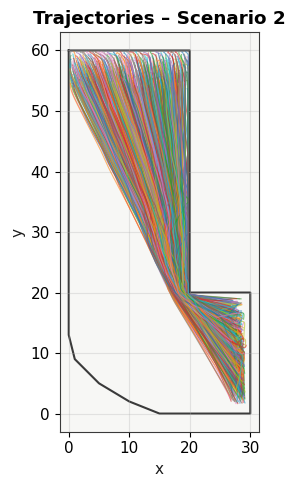

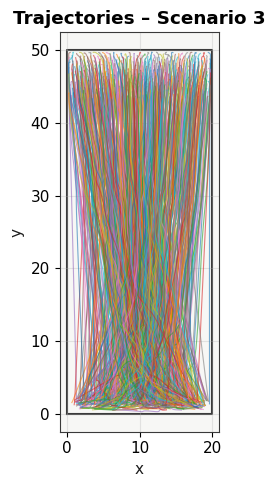

In [8]:
scenarios = [
    (df1, walkable1, "Scenario 1"),
    (df2, walkable2, "Scenario 2"),
    (df3, walkable3, "Scenario 3"),
]

for df, walkable, title in scenarios:
    fig, ax = plt.subplots()

    # plot walkable area (assumes a GeoDataFrame/shapely geometry with .boundary or .exterior)
    # adjust this depending on how your walkable is stored
    if hasattr(walkable, "plot"):
        walkable.plot(ax=ax, facecolor="none", edgecolor="#3a3a3a", linewidth=1.5, zorder=1)
    else:
        ax.plot(*walkable.exterior.xy, color="#3a3a3a", linewidth=1.5, zorder=1)

    # plot each agent's trajectory
    for agent_id, traj in df.groupby("id"):
        traj_sorted = traj.sort_values("frame")
        ax.plot(traj_sorted["x"], traj_sorted["y"], alpha=0.6, linewidth=0.8, zorder=2)

    ax.set_title(f"Trajectories – {title}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

## Acceptance - FAIL
RiMEA Test 15 expects Scenario 2 to have a evacuation time in between of Scenario 1 and 3. This is clearly not the case, corners have more effect on the behavior than they should have.

In [10]:
assert exit_times2["exit_time"].max() >= exit_times3["exit_time"].max() and exit_times2["exit_time"].max() <= exit_times1["exit_time"].max()
result1.cleanup()
result2.cleanup()
result3.cleanup()

AssertionError: 